In [19]:
# Model is for the dog vs Cat
%pip install gradio


Note: you may need to restart the kernel to use updated packages.


In [20]:
#|export 
from fastai.vision.all import *
import gradio as gr

def is_cat(x):
    return x[0].isupper()

In [3]:
path = untar_data(URLs.PETS)/'images'

In [4]:
path.ls()[:10]

[Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/pug_52.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/basset_hound_112.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/shiba_inu_122.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/leonberger_6.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'), Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/shiba_inu_136.jpg')]

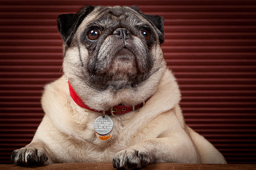

In [5]:
im = PILImage.create(path/'pug_52.jpg')
im.thumbnail((256,256))
im

In [6]:
dogs = [p for p in path.ls() if p.name.split('_')[0].lower() in [
    'beagle', 'bulldog', 'boxer', 'collie', 'dachshund', 'germanshepherd'
]]

dogs[:10]


[Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_147.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_153.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_184.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_190.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_22.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/boxer_36.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/beagle_138.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/beagle_104.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/beagle_21.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/beagle_35.jpg')]

In [7]:
cats = [p for p in path.ls() if p.name.split('_')[0].lower() in [
    'abyssinian', 'birman', 'bombay', 'persian', 'siamese', 'ragdoll'
]]

cats[:10]


[Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_193.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_53.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Birman_167.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_47.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Birman_173.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Abyssinian_225.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_187.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Abyssinian_219.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_90.jpg'),
 Path('/Users/sukhmeetsingh/.fastai/data/oxford-iiit-pet/images/Siamese_150.jpg')]

In [8]:
dls = ImageDataLoaders.from_name_func(
    '.', 
    get_image_files(path), valid_pct=0.2, seed= 42,
    label_func=is_cat,
    item_tfms=Resize(192)
)

In [ ]:
learn = vision_learner(dls, resnet18, metrics= error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.194918,0.036804,0.011502,01:02


epoch,train_loss,valid_loss,error_rate,time


In [ ]:
learn.export('model.pkl')

In [19]:
#|export
learn = load_learner("model.pkl")


/opt/miniconda3/lib/python3.13/site-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
%time learn.predict(im)

In [ ]:
#|export
categories = ('Dog', 'cat')

def classify_image(img):
    pred, idx, probs = learn.predict(img)
    return dict(zip(categories, map(float, probs)))

In [ ]:
classify_image(im)

In [ ]:
#|export

image = gr.Image(height=256, width=256)
label = gr.Label()

example = [
    'Egyptian_Mau_167.jpg',
    'pug_52.jpg',
    'beagle_104.jpg',
    'Abyssinian_219.jpg'
]

intf = gr.Interface(
    fn=classify_image,
    inputs=image,
    outputs=label,
    examples=example
)

intf.launch(inline=False)


In [16]:
from nbdev.export import notebook2script


In [22]:
notebook2script('app.ipynb')

OSError: [Errno 30] Read-only file system: '/settings.ini'